# Experiment 2: Comparing Observation Types over Generalized Circuits 

## Study Design

### Research Questions

> **RQ2**: How well does a PPO agent generalize over unseen procedurally generated circuits? 
>
> **RQ3**: How do Frenet observations compare with local LiDAR sensing?

### Design Matrix

The **medium PPO architecture** was selected from the Experiment 1 candidate set.

$2$ observation types are compared.
The hidden widths are kept fixed (the input dimensions differ), therefore the total number of training configurations is $2$.

Each training configuration is run $10$ times, using paired root identities `0` through `9`.
The total number of training runs is therefore $2 \times 10 = 20$:

| Algorithm | Actor | Observation | Roots |
|---|---|---|---:|
| PPO | Medium `(64, 64)` | Frenet | 10 |
| PPO | Medium `(64, 64)` | LiDAR | 10 |

### Fixed Conditions

Every run uses:

- The medium `(64, 64)` PPO actor selected from the original Experiment 1 candidate set before this rerun; the later tiny actor does not alter that selection;
- The learning rate selected before the experiment for PPO;
- A budget of $1\,000\,000$ training interactions;
- A deterministic evaluation over $16$ fixed validation circuits, every $50\,000$ training interactions;
- A checkpoint save every $250\,000$ interactions and at the end;
- A final test over $32$ fixed circuits.

### Learning Rates

Learning rates for PPO are selected using the same grid search as for Experiment 1.

The final **learning rates** are:

| Algorithm | Actor learning rate | Critic learning rate | 
|---|---:|---:|
| PPO | `3e-4` | `1e-2` |

## Experiment Results

**Status:** 20 completed training runs; ten paired roots; 1 million training interactions per run; a total of **126.7 minutes** (2.1h) of run time.

95% intervals use 10,000 whole-root bootstrap resamples with seed 0; paired comparisons retain root identities 0 through 9 in that order.

### RQ2 Generalization across Circuits

The table reports the final average performance with Frenet and LiDAR observation types after the full budget of 1M interactions:

| Metric at 1M | Frenet | **LiDAR** |
|---|---:|---:|
| Completed test laps | 315/320 | **318/320** |
| Mean completion | 0.9844 | **0.9938** |
| Completion 95% interval | [0.9688, 0.9969] | **[0.9813, 1.0000]** |
| Roots completing all 32 circuits | 6/10 | **9/10** |
| Mean maximum progress | 0.9903 | **0.9978** |
| Mean return ± across-root SD | 221.36 ± 7.48 | **233.21 ± 7.76** |
| Return 95% interval | [217.24, 226.03] | **[229.11, 238.05]** |
| Mean lap time (s), completed only | 25.64 | **23.45** |
| Crashed test laps | 5/320 | **2/320** |

Both representations generalize well and consistently over unseen circuits from the same generator family, although occasional crashes remain.

For context, the deterministic Frenet controller averaged $22.3s$ on a separate circuit set; this is an approximate reference, rather than a paired baseline on these test circuits.

### RQ3 Frenet vs LiDAR Observations

The final root-0 Frenet and LiDAR agents drive **test circuit 0** side by side, starting from the same canonical pose. Both advance on the same simulation clock. Each view freezes when its agent finishes, while the other continues.


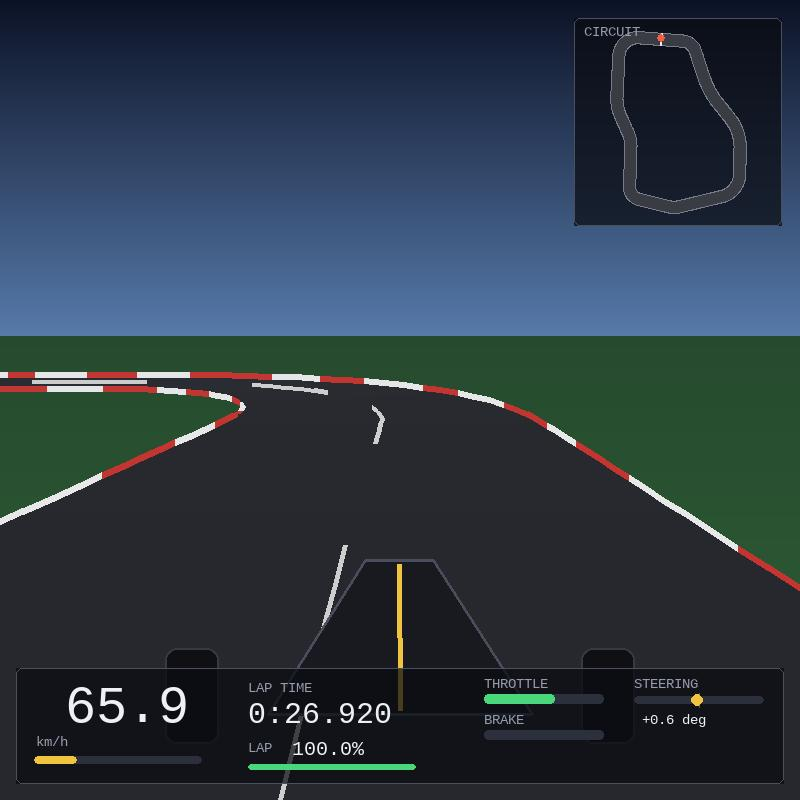
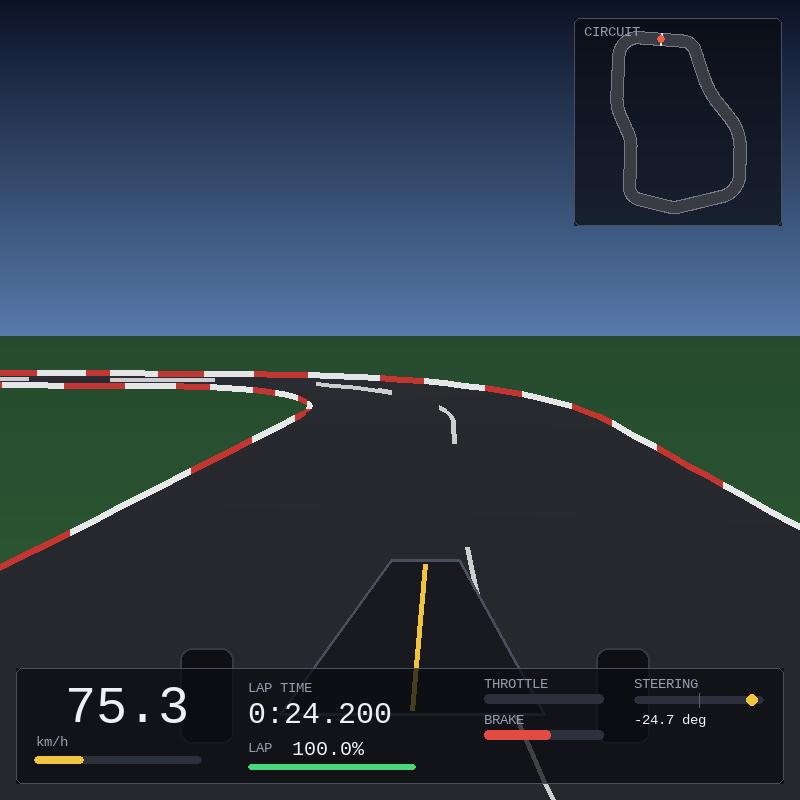

Frenet: completed=True, 26.92 s
Lidar: completed=True, 24.20 s


In [5]:
import json
from pathlib import Path
from time import sleep

from configs import EnvironmentConfig, StartStateConfig, TrackGenerationConfig
from envs import RacingEnv, TrackWithGeometry
from experiments.presentation_demo import RacingPairViewer, SavedActor

seed = 0
kinds = ("frenet", "lidar")
splits = json.loads(Path("tracks/experiment_2_splits.json").read_text())
circuit = splits["splits"]["test"]["circuits"][0]
track = TrackWithGeometry.generate(
    circuit["track_seed"],
    track_config=TrackGenerationConfig(**splits["track_generation"]),
)
runs = Path("results/reported_experiments/experiment_2_revised")
policies = [
    SavedActor.from_run(runs / f"ppo-medium-{kind}-seed-{seed}", seed=seed)
    for kind in kinds
]
environments = [
    RacingEnv(
        track,
        config=EnvironmentConfig(
            observation_type=kind, start=StartStateConfig(randomized=False)
        ),
        render_mode="rgb_array",
    )
    for kind in kinds
]
observations = [env.reset(seed=seed)[0] for env in environments]
frames = [env.render() for env in environments]
viewer = RacingPairViewer(frames, labels=("Frenet", "LiDAR"))
finished = [False, False]
infos = [None, None]

try:
    for step in range(environments[0].config.simulation.max_episode_steps):
        for index, (env, policy) in enumerate(zip(environments, policies, strict=True)):
            if finished[index]:
                continue
            action = policy.action(observations[index])
            observations[index], _, terminated, truncated, infos[index] = env.step(
                action
            )
            finished[index] = terminated or truncated
            if step % 2 == 0 or finished[index]:
                frames[index] = env.render()
        if step % 2 == 0 or all(finished):
            viewer.update(frames)
            sleep(2 * environments[0].config.simulation.agent_timestep)
        if all(finished):
            break
finally:
    for env in environments:
        env.close()

for kind, info in zip(kinds, infos, strict=True):
    print(
        f"{kind.title()}: completed={info['lap_completed']}, {info['elapsed_time']:.2f} s"
    )

### Final Performance and Convergence Speed

Although the two observation types both complete the task reliably, some differences can still be observed.

**LiDAR** has higher mean return and faster completed laps. Its completion advantage is only $0.94$ percentage points, with a paired 95% root-bootstrap interval of $[-0.94, 2.81]$ percentage points, so that difference remains uncertain.

For lap times, we retain only circuits completed by both policies in each root: **313 matched circuit pairs**, with 30-32 pairs per root. Averaging their Frenet-minus-LiDAR differences within each root gives **10 paired root measurements**. LiDAR is faster in eight of the ten roots, with a mean advantage of **2.21 s** and a 95% root-bootstrap interval of **[0.61, 3.72] s**.

An exact, two-sided [Wilcoxon signed-rank test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html) on those ten root means gives **$W=8$, $p=0.0488$**. The signed-rank interpretation assumes a symmetric distribution of root differences. This is an exploratory, unadjusted comparison conditional on mutual completion; the 313 circuit pairs are not independent training replications.

In [6]:
import csv

from scipy.stats import wilcoxon

with open("docs/tables/experiment_2_matched_laps.csv", encoding="utf-8") as file:
    pairs = list(csv.DictReader(file))
differences = [float(row["frenet_minus_lidar_lap_time"]) for row in pairs]
matched_circuits = sum(int(row["common_completed_circuit_count"]) for row in pairs)
result = wilcoxon(differences, alternative="two-sided", method="exact")
print(f"{len(pairs)} paired roots, {matched_circuits} matched circuit pairs")
print(f"W = {result.statistic:.0f}, two-sided p = {result.pvalue:.4f}")

10 paired roots, 313 matched circuit pairs
W = 8, two-sided p = 0.0488


Regarding learning efficiency, **LiDAR** reaches the validation threshold earlier on average: **110,000 interactions**, versus **185,000** for Frenet. This threshold requires at least **12/16 completed validation circuits** and median progress at least $0.95$ in three consecutive evaluations. First attainment is the first checkpoint in that streak; confirmation comes $100\,000$ interactions later, averaging **210,000** for LiDAR and **285,000** for Frenet.

All twenty roots attain the threshold. Nine Frenet roots and every LiDAR root first qualify by $200\,000$ interactions; the remaining Frenet root takes $650\,000$. The paired Frenet-minus-LiDAR first-attainment interval is **[-10,000, 195,000] interactions**, so the average speed advantage remains uncertain. Later regressions occur in both conditions; late validation completion averages **97.50% for LiDAR** and **92.03% for Frenet**.

<div style="display: flex; max-width: 1200px; width: 100%;">
  <img src="docs/figures/presentation/experiment_2_training_returns.png" alt="PPO exploratory training returns for Frenet and LiDAR" style="width: 50%; min-width: 0; object-fit: contain;">
  <img src="docs/figures/presentation/experiment_2_evaluation_returns.png" alt="PPO deterministic validation returns for Frenet and LiDAR" style="width: 50%; min-width: 0; object-fit: contain;">
</div>

These results are particularly interesting, as Frenet provides more direct track-relative features, while LiDAR preserves a different, more detailed local geometry description.

### Learned Control Policy

Plotting speed and throttle requests over distance on **test circuit 0, root 0**, illustrates differences between the final deterministic policies. Both complete the circuit: **26.92 s for Frenet** and **24.20 s for LiDAR**.

* The **Frenet** agent stays near $18m/s$ after launch, while **LiDAR** builds speed into the mid-to-high twenties and slows around corner sequences.
* **LiDAR** shows clearer acceleration and braking phases in this example. **Frenet** maintains relatively steady speed despite rapidly varying requests. These traces illustrate one pair of policies, rather than every root.

<div style="display: flex; max-width: 1200px; width: 100%;">
  <img src="docs/figures/presentation/experiment_2_speed.png" alt="Speed over distance for root 0 on test circuit 0" style="width: 50%; min-width: 0; object-fit: contain;">
  <img src="docs/figures/presentation/experiment_2_throttle.png" alt="Throttle and braking requests over distance for root 0 on test circuit 0" style="width: 50%; min-width: 0; object-fit: contain;">
</div>

A plausible hypothesis is that LiDAR's multiple ranges expose upcoming track layout that Frenet compresses into one curvature summary, helping the policy learn a more anticipatory speed schedule. Track-relative feedback may also accompany rapid corrective requests. The observation design does not force either behavior, and these traces do not establish the cause of the difference.

Across all test roots and circuits, LiDAR has fewer **steering-request reversals** ($8.13/s$ versus $13.61/s$), but its within-drive throttle SD is slightly higher ($0.52$ versus $0.49$). The clearest all-root smoothness difference is therefore in steering requests. Physical steering-rate and grip limits mediate those requests, and deterministic evaluation adds no exploration noise.


## Limitations and Future Work

* **One circuit-generator family** limits the generalization claim. Testing different generators, widths and corner structures would show whether the learned policies transfer beyond unseen seeds of this family.
* **Ten paired roots and rare failures** leave the small completion difference uncertain. More roots and more held-out circuits would improve precision; current root-bootstrap intervals are conditional on these 32 circuits.
* **Medium-based learning-rate tuning and unequal parameter counts** may affect the observation comparison. Equal hidden widths give LiDAR 10,949 actor-plus-critic parameters, versus 9,285 for Frenet; matched-parameter and separately tuned comparisons would help isolate the representation effect.
* **Partial observations and simplified physics** limit realism. Memory, sensor errors and altered vehicle dynamics are natural next tests.
